In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (mannwhitneyu,ttest_ind,chi2_contingency,kruskal,spearmanr,pointbiserialr)
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [30]:
data = pd.read_csv(r'D:\Creditcard_fraud_detection\data\raw\fraudTrain.csv')
# data = pd.read_csv(r'../data/raw/fraudTest.csv')

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [31]:
assert "is_fraud" in data.columns

print(data["is_fraud"].value_counts())
print("===================================")
print(data["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [32]:
## 4. Descriptive Statistics

# Descriptive statistics are used to summarize the numerical characteristics of the transaction dataset.

# The analysis includes:

# - Mean
# - Median
# - Standard deviation
# - Variance
# - Minimum
# - Maximum
# - Quartiles
# - Skewness
# - Kurtosis

In [33]:
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

descriptive_stats = data[numeric_cols].describe().T
descriptive_stats["variance"] = data[numeric_cols].var()
descriptive_stats["skewness"] = data[numeric_cols].skew()
descriptive_stats["kurtosis"] = data[numeric_cols].kurtosis()

descriptive_stats

,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis
Unnamed: 0,1296675.0,6.483370e+05,3.743180e+05,0.000000e+00,3.241685e+05,6.483370e+05,9.725055e+05,1.296674e+06,1.401139e+11,1.233496e-16,-1.200000
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18,1.712974e+36,2.851879e+00,6.179950
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04,2.570123e+04,4.227787e+01,4545.644979
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04,7.232454e+08,7.968076e-02,-1.096449
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01,2.576383e+01,-1.860277e-01,0.812968
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01,1.893122e+02,-1.150108e+00,1.855892
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06,9.117764e+10,5.593853e+00,37.614519
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09,1.648984e+14,3.377950e-03,-1.087541
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01,2.610994e+01,-1.819154e-01,0.795994
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01,1.896429e+02,-1.146960e+00,1.848479


In [34]:
fraud_group_stats = (data.groupby("is_fraud")[numeric_cols].agg(["count", "mean", "median", "std"]))

fraud_group_stats

Unnamed: 0                                           cc_num  \
              count           mean    median            std    count   
is_fraud                                                               
0           1289169  648473.169029  648411.0  374152.587321  1289169   
1              7506  624949.724354  638162.0  401056.008919     7506   

                                                        amt              \
                  mean        median           std    count        mean   
is_fraud                                                                  
0         4.172901e+17  3.521417e+15  1.308990e+18  1289169   67.667110   
1         4.003577e+17  3.528041e+15  1.276871e+18     7506  531.320092   

                                   zip                                       \
           median         std    count          mean   median           std   
is_fraud                                                                      
0          47.280  154.007971  1289169  48805.107481  48174.0  26890.987012   
1         396.505  390.560070     7506  48038.714229  46290.0  27265.558212   

              lat                                   long                      \
            count       mean   median       std    count       mean   median   
is_fraud                                                                       
0         1289169  38.536888  39.3543  5.075234  1289169 -90.228142 -87.4769   
1            7506  38.663609  39.4336  5.172289     7506 -89.916041 -86.6919   

                    city_pop                                      unix_time  \
                std    count          mean  median            std     count   
is_fraud                                                                      
0         13.755982  1289169  88775.228137  2456.0  301806.545204   1289169   
1         14.278221     7506  97276.763256  2623.0  326581.466670      7506   

                                                   merch_lat             \
                  mean        median           std     count       mean   
is_fraud                                                                  
0         1.349249e+09  1.349254e+09  1.283514e+07   1289169  38.536659   
1         1.348389e+09  1.348872e+09  1.383020e+07      7506  38.653901   

                              merch_long                                   \
             median       std      count       mean     median        std   
is_fraud                                                                    
0         39.365283  5.109144    1289169 -90.228274 -87.440911  13.767945   
1         39.427008  5.218387       7506 -89.915808 -86.813044  14.298685   

         is_fraud                   
            count mean median  std  
is_fraud                            
0         1289169  0.0    0.0  0.0  
1            7506  1.0    1.0  0.0

In [35]:
data.groupby("is_fraud")["amt"].agg(["count", "mean", "median", "std", "min", "max"])

,count,mean,median,std,min,max
is_fraud,,,,,,
0,1289169,67.667110,47.280,154.007971,1.00,28948.90
1,7506,531.320092,396.505,390.560070,1.06,1376.04


hypothesis testing

In [36]:
# Hypothesis Testing — Transaction Amount
# Research Question

# Is the distribution of transaction amounts different between fraudulent and legitimate transactions?

# Null Hypothesis (H0)

# There is no difference in the distribution of transaction amounts between fraudulent and legitimate transactions.

# Alternative Hypothesis (H1)

# The distributions of transaction amounts differ between fraudulent and legitimate transactions.

# Because transaction amount is potentially skewed, the Mann–Whitney U test is used as a robust non-parametric comparison.

In [37]:
fraud_amt = data.loc[data["is_fraud"] == 1, "amt"].dropna()
legit_amt = data.loc[data["is_fraud"] == 0, "amt"].dropna()

u_stat, p_value = mannwhitneyu(fraud_amt, legit_amt, alternative="two-sided")

print(f"U statistic : {u_stat:,.0f}")
print(f"p-value     : {p_value:.6e}")

U statistic : 8,075,744,868
p-value     : 0.000000e+00


conclusion

The Mann–Whitney U test indicates a statistically significant difference in the distribution of transaction amounts between fraudulent and legitimate transactions (U = 8,075,744,868, p < 0.001).
Therefore, transaction amount shows a statistically significant association with fraud status.
With your dataset containing around 1.3 million transactions, the p-value can be so extremely small that the numerical calculation underflows to approximately zero.


p-value ≈ 0     
p-value < 0.05

we reject H₀

###############################################################################################################################################
###############################################################################################################################################

Chi-square

Categorical Association Analysis

Research Question

Is transaction category statistically associated with fraud status?

H0

Transaction category and fraud status are independent.

H1

Transaction category and fraud status are associated.

The Chi-square test of independence is used.

In [38]:
contingency_table = pd.crosstab(data["category"], data["is_fraud"])

contingency_table

is_fraud,0,1
category,,
entertainment,93781,233
food_dining,91310,151
gas_transport,131041,618
grocery_net,45318,134
grocery_pos,121895,1743
health_fitness,85746,133
home,122917,198
kids_pets,112796,239
misc_net,62372,915


In [39]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {p_value:.6e}")

Chi-square statistic : 6486.0033
Degrees of freedom   : 13
p-value              : 0.000000e+00


In [40]:
gender_table = pd.crosstab(data["gender"],data["is_fraud"])

gender_table

is_fraud,0,1
gender,,
F,706128,3735
M,583041,3771


Correlation

In [41]:
numeric_col = data.select_dtypes(include=["int64", "float64"])
correlation_matrix = numeric_col.corr()

correlation_matrix

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
Unnamed: 0,1.000000,0.000386,-0.000251,0.000709,0.000602,-0.000676,-0.001678,0.998971,0.000541,-0.000671,-0.004767
cc_num,0.000386,1.000000,0.001769,0.041459,-0.059271,-0.048278,-0.008991,0.000354,-0.058942,-0.048252,-0.000981
amt,-0.000251,0.001769,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,-0.001873,-0.000151,0.219404
zip,0.000709,0.041459,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.113561,-0.908924,-0.002162
lat,0.000602,-0.059271,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.993592,-0.015509,0.001894
long,-0.000676,-0.048278,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,-0.015452,0.999120,0.001721
city_pop,-0.001678,-0.008991,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,-0.154781,-0.052687,0.002136
unix_time,0.998971,0.000354,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,0.000561,-0.000635,-0.005078
merch_lat,0.000541,-0.058942,-0.001873,-0.113561,0.993592,-0.015452,-0.154781,0.000561,1.000000,-0.015431,0.001741
merch_long,-0.000671,-0.048252,-0.000151,-0.908924,-0.015509,0.999120,-0.052687,-0.000635,-0.015431,1.000000,0.001721


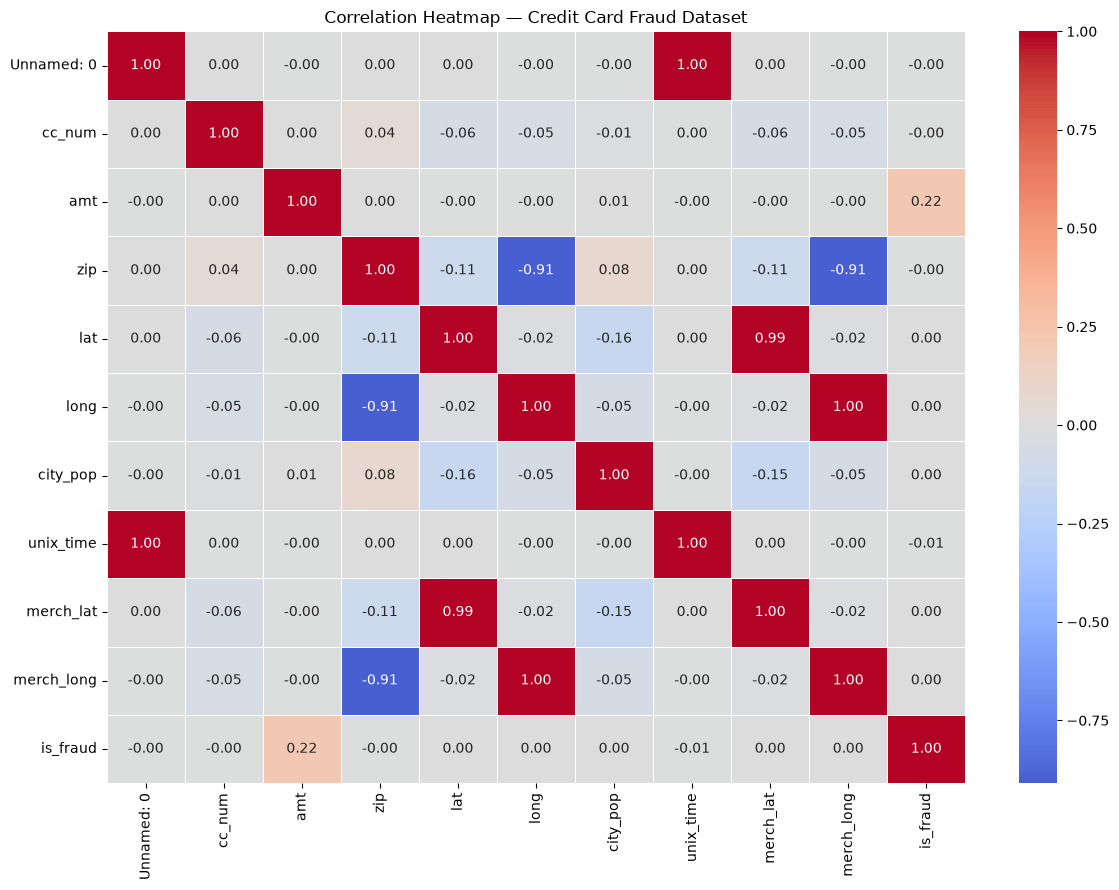

In [42]:
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0,linewidths=0.5)
plt.title("Correlation Heatmap — Credit Card Fraud Dataset")
plt.tight_layout()
plt.show()